<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/demos/day20_demo_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 20 Demo: Word Embedding
We'll train a simple model to predict the next word given a few words of context.

In the process, we'll learn a word embedding: a way to transform individual words into feature vectors that are useful for other tasks.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf

# Data

In [66]:
# The Clue Corpus
corpus = [
    "colonel mustard used the pipe in the library",
    "miss scarlett used the knife in the kitchen",
    "professor plum used the wrench in the study",
    "mrs peacock used the candlestick in the ballroom",
    "mr green used the revolver in the lounge",
    "the murderer used the knife in the library",
    "colonel mustard was seen in the kitchen",
    "miss scarlett was seen in the ballroom",
    "the wrench was found in the study"
]

# Configure TextVectorization
# We use this instead of our home-grown tokenizer from day 17
vectorizer = tf.keras.layers.TextVectorization(
    standardize="lower_and_strip_punctuation",
    output_mode="int" # could be tf_idf
)
vectorizer.adapt(corpus)

In [67]:
# get info from the vectorizer layer
vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)

# for looking up later
# v1 - dictionary comprehension
# word_to_index = {word: i for i, word in enumerate(vocab)}

# v2 - old school
word_to_index = {}
for i, word in enumerate(vocab):
    word_to_index[word] = i

print(f"Vocabulary Size: {vocab_size}")
print(f"Vocabulary: {word_to_index}")

Vocabulary Size: 29
Vocabulary: {'': 0, '[UNK]': 1, np.str_('the'): 2, np.str_('in'): 3, np.str_('used'): 4, np.str_('was'): 5, np.str_('wrench'): 6, np.str_('study'): 7, np.str_('seen'): 8, np.str_('scarlett'): 9, np.str_('mustard'): 10, np.str_('miss'): 11, np.str_('library'): 12, np.str_('knife'): 13, np.str_('kitchen'): 14, np.str_('colonel'): 15, np.str_('ballroom'): 16, np.str_('revolver'): 17, np.str_('professor'): 18, np.str_('plum'): 19, np.str_('pipe'): 20, np.str_('peacock'): 21, np.str_('murderer'): 22, np.str_('mrs'): 23, np.str_('mr'): 24, np.str_('lounge'): 25, np.str_('green'): 26, np.str_('found'): 27, np.str_('candlestick'): 28}


Run some new data through the vectorizer

In [68]:
X = ["Mr. Green put mustard on a hot dog in the kitchen",
     "Mrs. Peacock needs to study DMML in the Library"]
X = np.array(X)
vectorizer(X)

<tf.Tensor: shape=(2, 11), dtype=int64, numpy=
array([[24, 26,  1, 10,  1,  1,  1,  1,  3,  2, 14],
       [23, 21,  1,  1,  7,  1,  3,  2, 12,  0,  0]])>

## Generating CBOW Data
We need to slide a window across the sentences. For each window, the middle word is the label, y, and the surrounding words are the features, X.

In [69]:
window_size = 2
Xtrain = []
ytrain = []

# Vectorize the entire corpus first
vectorized_corpus = vectorizer(np.array(corpus)).numpy()

for seq in vectorized_corpus:
    # Filter out padding (0) if sentences are different lengths
    seq = [idx for idx in seq if idx != 0]

    for i in range(window_size, len(seq) - window_size):
        context = seq[i - window_size : i] + seq[i + 1 : i + window_size + 1]
        target = seq[i]
        Xtrain.append(context)
        ytrain.append(target)

Xtrain = np.array(Xtrain)
ytrain = np.array(ytrain)

In [70]:
print(corpus[0])
print(vectorized_corpus[0])

colonel mustard used the pipe in the library
[15 10  4  2 20  3  2 12]


In [71]:
Xtrain[:4]

array([[15, 10,  2, 20],
       [10,  4, 20,  3],
       [ 4,  2,  3,  2],
       [ 2, 20,  2, 12]])

In [72]:
ytrain[:4]

array([ 4,  2, 20,  3])

## The CBOW Model Architecture
Note how we use the GlobalAveragePooling1D layer to "squash" the context words into a single representation.

In [73]:
embedding_dim = 8  # Small dimension for a small demo

model = tf.keras.models.Sequential([
    # Input is the window of context words (window_size * 2)
    tf.keras.layers.Input(shape=(window_size * 2,)),

    # The Embedding Layer: This is what we actually want to learn!
    # Turns nonnegative integers (indexes) into vectors of fixed size.
    # Output will be (None, window_size * 2, embedding_dim)
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="w2v_embedding"),

    # Average the context word vectors (The "Bag of Words" part)
    # Output will be (None, embedding_dim)
    tf.keras.layers.GlobalAveragePooling1D(),

    # Predict the target word
    # Output will be (None, vocab_size)
    # which can be interpreted as a probability distribution
    # over the possible vocabulary words
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

opt = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy')

In [74]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ w2v_embedding (Embedding)       │ (None, 4, 8)           │           232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 29)             │           261 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493 (1.93 KB)

 Trainable params: 493 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
history = model.fit(Xtrain, ytrain, epochs=200, verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 714ms/step - loss: 3.3702
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3.3155
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.2671
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.2203
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.1740
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.1279
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.0797
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.0317
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.9835
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.9325
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.8819
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.8278
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.7737
Epoch 14/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.7167
Epoch 15/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.6587
Epoch 16/200
2/2 ━

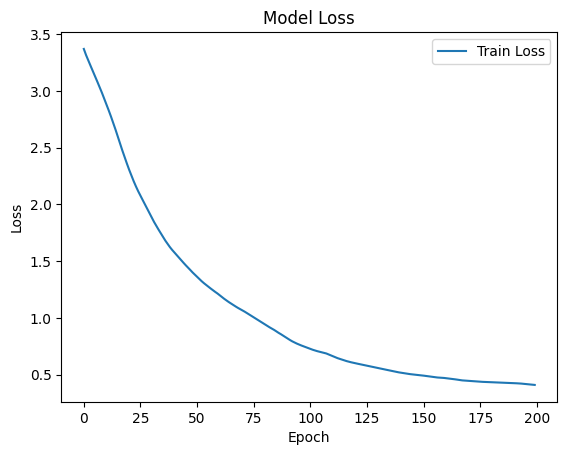

In [76]:
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


## Visualizing the Results

In [77]:
# Extract the weights from the embedding layer
weights = model.get_layer("w2v_embedding").get_weights()[0]
print(weights.shape)
# the weights are the embedded representation for each word
weights

(29, 8)


array([[-0.01021137, -0.01772063, -0.03962012, -0.01255133,  0.00324516,
        -0.02931718, -0.04023092, -0.00342193],
       [ 0.01485458, -0.02087563, -0.04679402, -0.00266309, -0.0444559 ,
         0.01381847,  0.02995143,  0.01844427],
       [ 0.59343237, -0.07857793, -0.42182228, -1.1151692 , -0.5854158 ,
        -1.8201386 , -0.48332503, -1.3828614 ],
       [-1.5655118 , -1.276254  ,  0.6347189 ,  0.4954483 ,  0.640638  ,
         1.600412  , -0.34618732, -0.20509002],
       [-2.3292158 , -0.47985846,  1.3476825 , -0.6811013 , -0.784501  ,
        -0.09661999, -1.0453901 ,  0.92430127],
       [-0.6552839 , -1.3486326 , -2.2562926 ,  0.13078716, -0.33372843,
         0.85329545,  0.64727235, -1.0135763 ],
       [ 0.7166021 , -0.31741285,  0.5780201 , -0.5463575 ,  0.6281629 ,
         1.0310221 ,  1.4785557 ,  0.01218262],
       [ 1.0769415 , -0.71697384, -1.2354392 , -0.6451301 , -1.0343475 ,
        -1.1950808 ,  0.73030466, -0.9623186 ],
       [ 1.6298665 , -1.1133475 

In [78]:
from sklearn.metrics.pairwise import cosine_similarity

def compare_words(word_a, word_b):
    vec_a = weights[word_to_index[word_a]]
    vec_b = weights[word_to_index[word_b]]
    similarity = cosine_similarity([vec_a], [vec_b])

    # similarity is a list of lists for some reason
    return similarity[0][0]

# Demo matches
a = 'mustard'
b = 'scarlett'
sim = compare_words(a, b)  # Both are suspects
print(f"Similarity between '{a}' and '{b}': {sim:.4f}")

a = 'mustard'
b = 'kitchen'
sim = compare_words(a, b)  # Both are suspects
print(f"Similarity between '{a}' and '{b}': {sim:.4f}")


Similarity between 'mustard' and 'scarlett': 0.9706
Similarity between 'mustard' and 'kitchen': -0.1421


## Classification model
We can use the embedding weights learned above in a classification model.

This is similar to transforming text into tf-idf vectors, but instead we'll transform text into our learned embeddings.


In [79]:
# Extract the weights from the embedding layer
learned_weights = model.get_layer("w2v_embedding").get_weights()[0]

# get info from the vectorizer layer
vocab = vectorizer.get_vocabulary()

# Build the Classifier
classifier_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,), dtype=tf.string),
    tf.keras.layers.TextVectorization(vocabulary=vocab), # Use same vocab
    tf.keras.layers.Embedding(vocab_size, embedding_dim, weights=learned_weights, trainable=False),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax') # Suspect, Weapon, or Room
])

classifier_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Make some classification data

In [80]:
# Categories: 0 = Suspect, 1 = Weapon, 2 = Room
clue = [
    "Colonel Mustard", "Professor Plum", "Miss Scarlet", "Mrs Peacock",
    "the Lead Pipe", "the Candlestick", "a Revolver", "the Dagger",
    "the Kitchen", "the Conservatory", "the Billiard Room", "the Ballroom"
]

# Labels for classification (Suspect, Weapon, Room)
labels = [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2]

Xtrain = tf.Variable(clue)
ytrain = tf.Variable(labels)

Xtest = tf.Variable(['professor plum', 'mr green', 'the rope', 'the dining room'])
ytest = [0, 0, 1, 2]

In [81]:
# Train the model
history = classifier_model.fit(
    Xtrain,
    ytrain,
    epochs=20,
    batch_size=2,
    verbose=1
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2500 - loss: 1.3391     
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2500 - loss: 1.3140    
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2500 - loss: 1.3033    
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2500 - loss: 1.2949    
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2500 - loss: 1.2451    
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2500 - loss: 1.2347
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1667 - loss: 1.1990    
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2500 - loss: 1.1763    
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2500 - loss: 1.1636    
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2500 - loss: 1.1443    
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2500 - loss: 1.1338    
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms

## Testing

In [82]:
# predictions will have one column per possible class
preds = classifier_model(Xtest)
preds

<tf.Tensor: shape=(4, 3), dtype=float32, numpy=
array([[0.29800695, 0.37943196, 0.32256112],
       [0.3087975 , 0.36750564, 0.32369685],
       [0.22157761, 0.30779606, 0.47062626],
       [0.22440682, 0.30876815, 0.466825  ]], dtype=float32)>

In [83]:
# find the predicted label using argmax
ypred = np.argmax(preds, axis=1)
ypred

array([1, 1, 2, 2])